<a href="https://colab.research.google.com/github/LeMonAdE4800/sc3021-project-grp-2/blob/main/SC3021_Group_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#All relevant imports for the notebook
import pandas as pd
import matplotlib.pyplot as plt
import requests
import datetime
from datetime import datetime
import sqlite3
import numpy as np
from scipy import stats

# **Does student lifestyle affect academic performance?**

## Hypothesis/analysis goal (Ask)



> *Clearly state the data science hypothesis / the analytical goal you pursue in your project. From your description, it should be clear which question you address, what type of analysis is needed, and what quality metric is targeted.*



Students across the world study different disciplines and have different strengths and weaknesses, and academic performance is influenced by multiple factors, among which study habits, sleep patterns and class attendance are often considered critical. We want to find out if and how these student lifestyle affect their academic performances in school, regardless of discipline. We hypothesise that students that have a healthy lifestyle and put in effort for their studies will have better academic performance. In this context, we will explore the possible correlations between different ways students put in effort and how it affects their final score or grade. We separate student efforts from their given circumstances and backgrounds, as we acknowledge that financial support and parents' education levels, among many other factors, can play significant roles in improving students' results, but are not a result of their own efforts.

Exploratory data analysis will be used to understand relationships between variables. By identifying statistically significant correlations and patterns, the analysis seeks to identify which influential factors strongly associate with academic success and to assess the predictive power of student effort and lifestyle variables on academic performance.

## Data source identification and exploration (Prepare)




>*Make a brief requirements analysis for the data and data sources that you require to reach your goal.*





**Requirement analysis.**

To address this problem, we require data that captures both academic outcomes and effort or lifestyle-related variables :

*   Study effort variables (e.g. daily study hours, attendance rate)
*   Lifestyle variables (e.g. average sleep duration).
*   Academic performance indicators (e.g. exam scores, grades)

Each data record should correspond to one student. The dataset should contain a sufficiently large and diverse sample to ensure reliable statistical analysis.






> *List the sources you will report on for Deliverable 1 and link them to where you found them. In selecting which datasets you want to report on for exploration, take note of the following: (1) The subsequent data preparation and analysis should rely on at least 3 datasets; (2) the discussion concerning exploration needs to feature arguments for why datasets were selected and why others were not.*




**List of considered sources.**
Below are example datasets that could be considered and explored.

*   **Student Academic Performance Sheet**
  * [student_lifestyle_dataset.csv](https://www.kaggle.com/datasets/steve1215rogg/student-lifestyle-dataset)
*  [Students Performance Dataset.csv](https://www.kaggle.com/datasets/mahmoudelhemaly/students-grading-dataset)
*  [Student Insomnia and Educational Outcomes Dataset](https://data.mendeley.com/datasets/5mvrx4v62z/3)

>*For further processing, the data first needs to be loaded. As sample_data is flushed regularly, you may mount a personal Google Drive to read data from there while working on your project. However, your deliverables must include code to read in data from the temporary sample_data folder, where we will upload the data referenced above for evaluation. Therefore, make sure the provided link / information refers to a specific file.*

### Guideline: Dataset exploration discussion



> We acknowledge that each dataset requires different exploration steps to come to the conclusion whether or not to use it. Therefore, no detailed guideline can be given, but we recommend incorporating the following sections:
*   Brief description of downloaded data and reflection on how well it matches requirements or how it is amenable to match the requirements.
*   Profiling steps that should include a short description, the code to execute these, and an interpretation and critical discussion of the results with respect to the suitability of the dataset for addressing the analytical task.
* Discussion of the quality of the data relating to aspects to be considered during data preparation and analysis. It should refer to at least two different quality criteria per explored dataset, one beign assessed positively and one assessed as problematic.
* Concluding paragraph that summarizes (non-)suitability and important points to take note of if the dataset is selected to be used.  






### DS1: Student Performance Factors Datasheet

**Description**. This CSV file was downloaded from Kaggle. The data was collected via a Google Forms survey.
This dataset contains 2,000 records of students' daily habits across study, extracurriculars, sleep, socializing, and physical activities. It provides a detailed view of student lifestyle patterns and their correlation with academic performance, represented by GPA.
We will only process and utilise data on sleep hours, study hours and final grade received.

In [ ]:
#Get table data from a the csv file about StudentPerformanceFactors, the file from the
#Kaggle repository we use

# Read in the csv file into a DataFrame
df = pd.read_csv('/content/student_lifestyle_dataset.csv')

# Print the first 5 rows of the DataFrame to verify it loaded correctly
print(df)


      Student_ID  Study_Hours_Per_Day  Extracurricular_Hours_Per_Day  \
0              1                  6.9                            3.8   
1              2                  5.3                            3.5   
2              3                  5.1                            3.9   
3              4                  6.5                            2.1   
4              5                  8.1                            0.6   
...          ...                  ...                            ...   
1995        1996                  6.5                            0.2   
1996        1997                  6.3                            2.8   
1997        1998                  6.2                            0.0   
1998        1999                  8.1                            0.7   
1999        2000                  9.0                            1.7   

      Sleep_Hours_Per_Day  Social_Hours_Per_Day  \
0                     8.7                   2.8   
1                     8.0        

Looking at the data, we see that the data contains variables such as sleep hours, social hours, extracurricular hours, study hours, and physical activity hours. The stress level is self-assessed by the survey participants. It also includes the required changed variable that is being compared, grades of the students in terms of Grade Point Average.

The granularity for grades is sufficient, with GPA given up to 2 decimal points. The time granularity is also sufficient, up to 1 decimal point, to determine the relationship between the hours spent doing different activities and the students' grades. For the purpose of this analysis, only the study hours, sleep hours and grades attributes will be used.

**Exploring the teams covered in the dataset**



> *As per the project guide, you are allowed to use generative AI to support you. This exemplar embeds one example of the required paper trail of GAI use. You are required to report every use analogously in a separate file that is to be handed in with Deliverable 3.*



Required info | Your answer
-------------------|------------------
GenAI tool name | Google Colab integrated code generator
Input prompt |  List the distinct teams in the dataset
Generated output |see comment in DS1 - code cell 2
Impacted notebook cell | DS1 - code cell 2

In [ ]:
# prompt: List the distinct teams in the dataset

### ORIGINAL GAI OUTPUT
### Assuming 'df' is the DataFrame loaded from 'Match_Results.csv' as shown in the provided code.
### distinct_teams = df['home_team'].unique()
### distinct_teams

# Get the unique teams from both the 'home_team' and 'away_team' columns
unique_teams = pd.concat([df['home_team'], df['away_team']]).unique()

# Print the list of unique teams
print(unique_teams)


['Scotland' 'England' 'Wales' 'Northern Ireland' 'United States' 'Uruguay'
 'Austria' 'Hungary' 'Argentina' 'Belgium' 'France' 'Guernsey' 'Jersey'
 'Netherlands' 'Czechoslovakia' 'Alderney' 'Switzerland' 'Sweden'
 'Germany' 'Italy' 'Chile' 'Norway' 'Finland' 'Luxembourg' 'Russia'
 'Denmark' 'Catalonia' 'Philippines' 'Basque Country' 'China PR' 'Brazil'
 'Japan' 'Paraguay' 'Canada' 'Estonia' 'Costa Rica' 'Guatemala' 'Spain'
 'Brittany' 'Poland' 'Yugoslavia' 'New Zealand' 'Romania' 'Latvia'
 'Galicia' 'Portugal' 'Andalusia' 'Australia' 'Lithuania' 'Turkey'
 'Central Spain' 'Mexico' 'Aruba' 'Egypt' 'Republic of Ireland' 'Haiti'
 'Bulgaria' 'Jamaica' 'Kenya' 'Bolivia' 'Peru' 'Honduras' 'Guyana'
 'Uganda' 'Belarus' 'El Salvador' 'Barbados' 'Trinidad and Tobago'
 'Greece' 'Cuba' 'Curaçao' 'Dominica' 'Silesia' 'Guadeloupe' 'Israel'
 'Suriname' 'French Guiana' 'Panama' 'Colombia' 'Venezuela' 'Ecuador'
 'Saint Kitts and Nevis' 'Slovakia' 'Manchukuo' 'Croatia' 'Nicaragua'
 'Afghanistan' 'India' 

From the above program, we gather that teams limit to national teams. We assume that this is fine for the application but are aware that limiting to these highly professional teams, our prediction may be affected as the players may be less affected by weather conditions (as they perform well no matter the weather).

**Exploration of covered countries**

In [ ]:
# prompt: SELECT country, COUNT(*) FROM table GROUP BY country ORDER BY COUNT(*) DESC

# Assuming 'df' is your DataFrame with the match data
country_counts = df.groupby('country')['country'].count().sort_values(ascending=False)
print(country_counts)


country
United States          1399
France                  889
Malaysia                813
England                 745
Qatar                   701
                       ... 
Portuguese Guinea         1
Mali Federation           1
Micronesia                1
Bohemia and Moravia       1
Belgian Congo             1
Name: country, Length: 270, dtype: int64


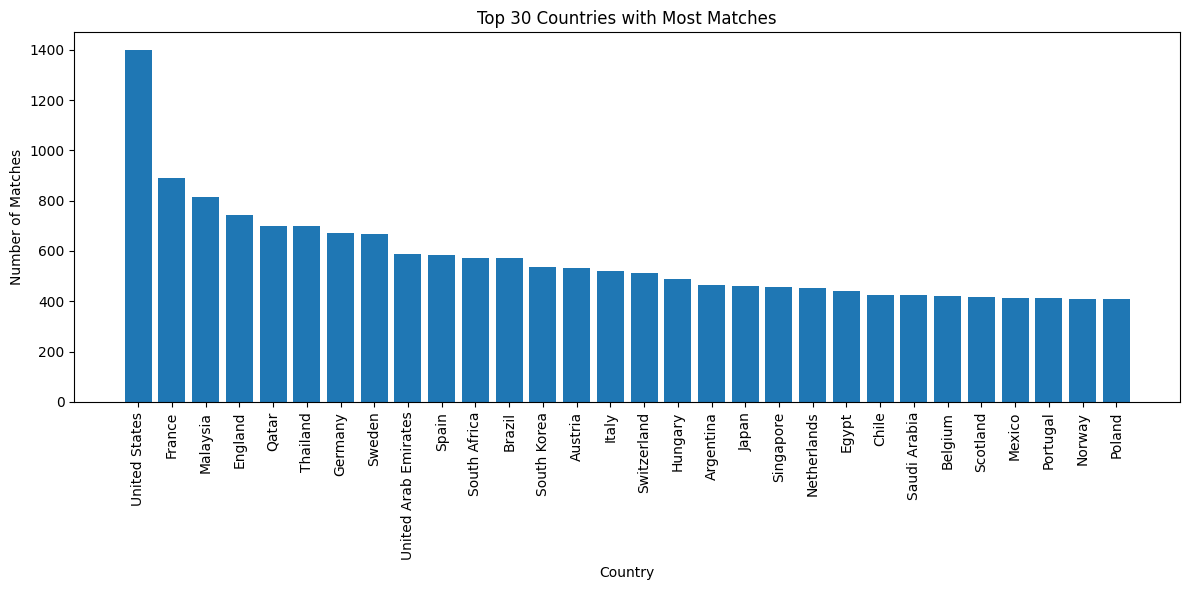

In [ ]:
# Select the top 30 countries in terms of number of appearance in the data,
# according to country_counts
top_30_countries = country_counts.head(30)

# Create a histogram
plt.figure(figsize=(12, 6))
plt.bar(top_30_countries.index, top_30_countries.values)
plt.xlabel('Country')
plt.ylabel('Number of Matches')
plt.title('Top 30 Countries with Most Matches')
plt.xticks(rotation=90)  # Rotate x-axis labels for readability
plt.tight_layout()
plt.show()


Overall, we observe that most countries are covered, but the frequency of matches in countries highly varies. This may introduce some bias during analysis if the training data is dominated by one climate region. In the plot showing the top-30 countries in terms of number of matches, we observe that countries from different climatic zones are included (US cover more than just one, then central European like France and Germany are covered, Qatar and UAE with dry desert climate, Malaysia and Singapore with tropical climate), so different weather conditions should be present in the data (but to different degree, which may lead to bias as discussed before). As part of data preparation, we will take special care in creating a balanced dataset to avoid bias.

**Exploring covered tournaments**

In [ ]:
# List all the distinct tournament values

# Determine distinc tournaments
distinct_tournaments = df['tournament'].unique()

# Print the list of distinct tournaments
print(distinct_tournaments)


['Friendly' 'British Home Championship' 'Évence Coppée Trophy'
 'Muratti Vase' 'Copa Lipton' 'Copa Newton' 'Copa Premio Honor Argentino'
 'Copa Premio Honor Uruguayo' 'Far Eastern Championship Games' 'Copa Roca'
 'Copa América' 'Peace Cup' 'Open International Championship'
 'Copa Chevallier Boutell' 'Olympic Games' 'Nordic Championship'
 'Central European International Cup' 'Baltic Cup' 'Balkan Cup'
 'Central American and Caribbean Games' 'FIFA World Cup' 'Copa Rio Branco'
 'FIFA World Cup qualification' 'Bolivarian Games' 'CCCF Championship'
 'NAFC Championship' 'Copa Oswaldo Cruz' 'Asian Games'
 'Pan American Championship' 'Copa del Pacífico' "Copa Bernardo O'Higgins"
 'AFC Asian Cup qualification' 'Atlantic Cup' 'AFC Asian Cup'
 'African Cup of Nations' 'Copa Paz del Chaco' 'Merdeka Tournament'
 'UEFA Euro qualification' 'Southeast Asian Peninsular Games'
 'African Friendship Games' 'UEFA Euro' 'Windward Islands Tournament'
 'African Cup of Nations qualification' 'Vietnam Independen

A wide range of worldwide tournaments is covered, the dataset thereby is representative of a large variety of national teams playing at various levels across the world. This may alleviate the previously identified problem of focusing the analysis on national teams only.

**Data quality considerations**

We highlight the following quality criteria that we assessed (among others) to determine the suitability of the dataset for our task:


*   In terms of completeness, the dataset satisfies our requirement for the task at hand as it is quite comprehensive in the coverage of mational team matches worldwide, i.e., presents match data in sufficient breadth, depth, and scope.
*   The interpretability of the dataset is high, given that it limits to few essential attributes with clear semantics. This makes misinterpretation and misuse highly during analysis highly unlikely.
* While the reputation of Kaggle is good in the data science community, the reputation of the dataset remains unclear. No authors are listed on the Kaggle web page and the provenance remains vague (e.g.,sources not named, no mention of quality check of automatically scraped data).

Despite the moderate reputation, the dataset ideally fits our data requirements so we eventually opted to use it. We are however aware that potential errors in the data can affect the accuracy of the trained model.


**Conclusion for Kaggle football dataset**

In light of the above data exploration, we consider the dataset suited for our analysis with the following caveats, which we will keep in mind during data preparation and analysis:

*   Locations may exhibit an overrepresentation of some climate zones, which may need to be countered by appropriate sampling of the training data.
*   Due to unclear source reputation, our model may be based on erroneous data. Cross-validating the data using authoritative sources or studying how transferrable the model is to other input data are possible options to mitigate this problem, but are not further considered within the scope of this mini-project.




### DS2: Student Performance & Behaviour Dataset from Kaggle

**Description.** We downladed the CSV file from Kaggle on 30/01/2026. It contains 23 attributes, such as extracurricular activities, internet access and parent education level, which are not all relevant to our analysis. Therefore, we project only the relevant data into the DataFrame for further processing. These attributes relate to student id, attendance percentage, exam scores, study hours per week and sleep hours per night.

Each row corresponds to an individual student.The presence of study hours, sleep hours and attendance rate allows us to analyze multiple dimensions of student effort and lifestyle simultaneously, and the academic performance variable serves as an outcome measure. The data are all at the necessary granularity for our application.


In [ ]:
#Get table data from a the csv file about Student Performance Dataset, the file from the
#Kaggle repository we use

# Read in the csv file into a DataFrame
df = pd.read_csv('/content/Students Performance Dataset.csv')

# Print the first 5 rows of the DataFrame to verify it loaded correctly
print(df)


     Student_ID First_Name Last_Name                       Email  Gender  Age  \
0         S1000       Omar  Williams     student0@university.com  Female   22   
1         S1001      Maria     Brown     student1@university.com    Male   18   
2         S1002      Ahmed     Jones     student2@university.com    Male   24   
3         S1003       Omar  Williams     student3@university.com  Female   24   
4         S1004       John     Smith     student4@university.com  Female   23   
...         ...        ...       ...                         ...     ...  ...   
4995      S5995      Ahmed     Jones  student4995@university.com    Male   19   
4996      S5996       Emma     Brown  student4996@university.com    Male   19   
4997      S5997       John     Brown  student4997@university.com  Female   24   
4998      S5998       Sara     Davis  student4998@university.com    Male   23   
4999      S5999      Maria     Brown  student4999@university.com  Female   21   

       Department  Attendan

In [ ]:
# prompt: list column labels from the CSV file sample_data/matches_1930_2022.csv

# Read the CSV file into a DataFrame
df_matches = pd.read_csv('/content/Students Performance Dataset.csv')

# Get the column labels (header)
column_labels = df_matches.columns.tolist()

# Print the column labels
print(column_labels)


['Student_ID', 'First_Name', 'Last_Name', 'Email', 'Gender', 'Age', 'Department', 'Attendance (%)', 'Midterm_Score', 'Final_Score', 'Assignments_Avg', 'Quizzes_Avg', 'Participation_Score', 'Projects_Score', 'Total_Score', 'Grade', 'Study_Hours_per_Week', 'Extracurricular_Activities', 'Internet_Access_at_Home', 'Parent_Education_Level', 'Family_Income_Level', 'Stress_Level (1-10)', 'Sleep_Hours_per_Night']


In [ ]:
# prompt: Only select the relevant columns Student_ID, Attendance (%), Final_Score, Study_Hours_per_Week, Sleep_Hours_per_Night

# Select only the relevant columns
df_selected = df[['Student_ID', 'Attendance (%)', 'Final_Score', 'Study_Hours_per_Week', 'Sleep_Hours_per_Night']]

# Print the first few rows of the new DataFrame to verify
print(df_selected.head())


  Student_ID  Attendance (%)  Final_Score  Study_Hours_per_Week  \
0      S1000           97.36        59.61                  10.3   
1      S1001           97.71        74.00                  27.1   
2      S1002           99.52        63.85                  12.4   
3      S1003           90.38        44.44                  25.5   
4      S1004           59.41        61.77                  13.3   

   Sleep_Hours_per_Night  
0                    5.9  
1                    4.3  
2                    6.1  
3                    4.9  
4                    4.5  


**Profiling academic department coverage**

We perform some data profiling on the data to better understand the academic departments it covers, whether the distribution of students across departments is sufficiently broad and balanced for analyzing the relationship between student lifestyle and effort and academic performance.

In [ ]:
# prompt: Display a table that shows the number of students per department

# Calculate the number of students per department
department_counts = df.groupby('Department')['Department'].count()

# Create a table showing the number of matches per home team and per host
print("Number of students per department:")
print(department_counts)

Number of students per department:
Department
Business       1264
CS             1239
Engineering    1274
Mathematics    1223
Name: Department, dtype: int64


Looking at the above statistics, we observe that the dataset covers multiple academic departments, providing diversity in academic contexts and the student representation across departments is highly balanced, with no department substantially dominating the dataset.

In this context, the purpose of profiling department coverage is not to compare performance across departments or to infer department-specific effects. Instead, it serves as a data quality and coverage check, ensuring that the dataset is not implicitly biased toward a particular academic discipline.

**Quality considerations**

We summarize key quality aspects as follows:


*   The dataset exhibits relatively low levels of missing data across the main variables of interest. This helps preserve the integrity of correlation analysis.

*   Several effort-related variables, such as study hours and sleep hours are self-reported, which may be subject to reporting bias or inaccuracies, which can weaken the observed relationships between variables. In addition, the dataset does not provide detailed metadata which may introduce ambiguity.

These limitations will be acknowledged in subsequent analysis and discussion, and results will be interpreted as associative rather than causal.



**Conclusions**

In conclusion, the Students Performance and Behaviour Dataset is largely suitable for investigating correlation between student lifestyle and effort and academic performance. It directly includes the key variables required for our analysis and demonstrates acceptable data completeness and structure.

### DS3: Student Insomnia and Educational Outcomes Dataset

**Description.**

The Student Insomnia and Educational Outcomes Dataset is a Mendeley dataset downloaded on 30/01/2026 containing relationships between sleep habits, health-related factors, academic effort, and perceived academic performance collected through an online survey administered via Google Forms. This dataset aligns well with the task of studying how student effort and health (specifically sleep and stress) affect academic performance, as it directly measures both health-related predictors and academic outcome indicators.

In [ ]:
#Get table data from a the csv file about StudentPerformanceFactors, the file from the
#Kaggle repository we use

# Read in the csv file into a DataFrame
import pandas as pd
df = pd.read_csv('/content/Student Insomnia and Educational Outcomes Dataset.csv')

# Print the first 5 rows of the DataFrame to verify it loaded correctly
print(df)


               Timestamp 1. What is your year of study?  \
0    10/24/2024 16:51:15               Graduate student   
1    10/24/2024 16:51:51                     Third year   
2    10/24/2024 16:52:21                     First year   
3    10/24/2024 16:53:00                     Third year   
4    10/24/2024 16:53:25               Graduate student   
..                   ...                            ...   
786   11/6/2024 19:10:52                     Third year   
787   11/6/2024 19:11:25               Graduate student   
788   11/6/2024 19:12:31               Graduate student   
789   11/6/2024 19:14:33               Graduate student   
790   11/6/2024 19:15:41                     Third year   

    2. What is your gender?  \
0                      Male   
1                      Male   
2                    Female   
3                      Male   
4                      Male   
..                      ...   
786                    Male   
787                    Male   
788         

**Profiling Steps of DS3**

The first step was to inspect the dataset’s structure, size, and data types.

In [ ]:
import pandas as pd

df = pd.read_csv("Student Insomnia and Educational Outcomes Dataset.csv")
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 791 entries, 0 to 790
Data columns (total 16 columns):
 #   Column                                                                                                                   Non-Null Count  Dtype 
---  ------                                                                                                                   --------------  ----- 
 0   Timestamp                                                                                                                791 non-null    object
 1   1. What is your year of study?                                                                                           791 non-null    object
 2   2. What is your gender?                                                                                                  791 non-null    object
 3   3. How often do you have difficulty falling asleep at night?                                                             791 non-null    object
 

Next, to understand how responses are distributed across key variables, frequency counts were examined.

In [ ]:
print(df["4. On average, how many hours of sleep do you get on a typical day?"].value_counts())
print(df["15. How would you rate your overall academic performance (GPA or grades) in the past semester?"].value_counts())

4. On average, how many hours of sleep do you get on a typical day?
7-8 hours            423
More than 8 hours    333
6-7 hours             24
4-5 hours              7
Less than 4 hours      4
Name: count, dtype: int64
15. How would you rate your overall academic performance (GPA or grades) in the past semester?
Poor             419
Below Average    297
Average           52
Good              17
Excellent          6
Name: count, dtype: int64


Variables were grouped conceptually into predictors and outcomes:

* Health indicators: sleep duration, insomnia frequency, sleep quality, fatigue

* Effort and engagement indicators: class attendance, concentration difficulty, assignment completion

* Outcome variable: overall academic performance

This is because the dataset includes multiple variables that conceptually overlap (e.g., fatigue and concentration difficulty), which may introduce redundancies.

In [ ]:
healthVars = [
    '3. How often do you have difficulty falling asleep at night?',
    '4. On average, how many hours of sleep do you get on a typical day?',
    '5. How often do you wake up during the night and have trouble falling back asleep?',
    '6. How would you rate the overall quality of your sleep?',
    '8. How often do you feel fatigued during the day, affecting your ability to study or attend classes?',
    '12. How often do you consume caffeine (coffee, energy drinks) to stay awake or alert?',
    '13. How often do you engage in physical activity or exercise?'
]
effortVars = [
    '7. How often do you experience difficulty concentrating during lectures or studying due to lack of sleep?',
    '9. How often do you miss or skip classes due to sleep-related issues (e.g., insomnia, feeling tired)?',
    '10. How would you describe the impact of insufficient sleep on your ability to complete assignments and meet deadlines?'
]
stressVars = [
    '14. How would you describe your stress levels related to academic workload?'
]
outcomeVar = [
    '15. How would you rate your overall academic performance (GPA or grades) in the past semester?'
]
healthDf = df[healthVars]
effortDf = df[effortVars]
stressDf = df[stressVars]
outcomeDf = df[outcomeVar]

orderedColumns = healthVars + effortVars + stressVars + outcomeVar

for col in orderedColumns:
    print(col)



3. How often do you have difficulty falling asleep at night?
4. On average, how many hours of sleep do you get on a typical day?
5. How often do you wake up during the night and have trouble falling back asleep?
6. How would you rate the overall quality of your sleep?
8. How often do you feel fatigued during the day, affecting your ability to study or attend classes?
12. How often do you consume caffeine (coffee, energy drinks) to stay awake or alert?
13. How often do you engage in physical activity or exercise?
7. How often do you experience difficulty concentrating during lectures or studying due to lack of sleep?
9. How often do you miss or skip classes due to sleep-related issues (e.g., insomnia, feeling tired)?
10. How would you describe the impact of insufficient sleep on your ability to complete assignments and meet deadlines?
14. How would you describe your stress levels related to academic workload?
15. How would you rate your overall academic performance (GPA or grades) in th

**Quality considerations**



*   The dataset contains no missing values, which makes the dataset reliable for exploratory data analysis and modeling without extensive cleaning.
*   However, all variables, including academic performance and sleep quality, are self-reported, introducing potential bias.
* Sleep duration is reported in ranges rather than exact hours, reducing numerical precision.
* Academic performance is measured subjectively rather than via actual GPA or grades.




**Conclusion**

Overall, the Student Insomnia and Educational Outcomes Dataset is adequate for our analysis of how sleep, health, and academic effort relate to student performance. Its strengths include a large sample size, complete data and strong conceptual alignment with our task.

## Data Preparation (Process)



> *In this section, describe, justify, and implement transoformation and profiling tasks to prepare the data you have selected for later analysis. Structure the section as follows:
*   Overview: provides a summary of the transformations performed, reffering to the specific types of operations discussed in class. Should include a visualization of the transformation pipeline.
*   For each individual operation (task), briefly describe what it does using terms defined in class, why you perform it, and implement it.





### Overview

As part of data preparation, we implement the transformation and profiling tasks summarized in the diagram below. Relying on the data obtained from CSV files in DS1 and DS4, we retain only their necessary attributes and build an integrated dataset. Upon profiling missing values, we opt to leverage data that was incrementally obtained from DS5 (due to daily access quotas) to impute missing values in the weather data. Next, we enrich the data with two additional attributes: one binary attribute distinguishing friendly matches from competitive matches and one categorical attribute defining the climate zone of a match location. Profiling the value distribution of these new attributes yields satisfactory results and we persistently store the prepared dataset before further processing.

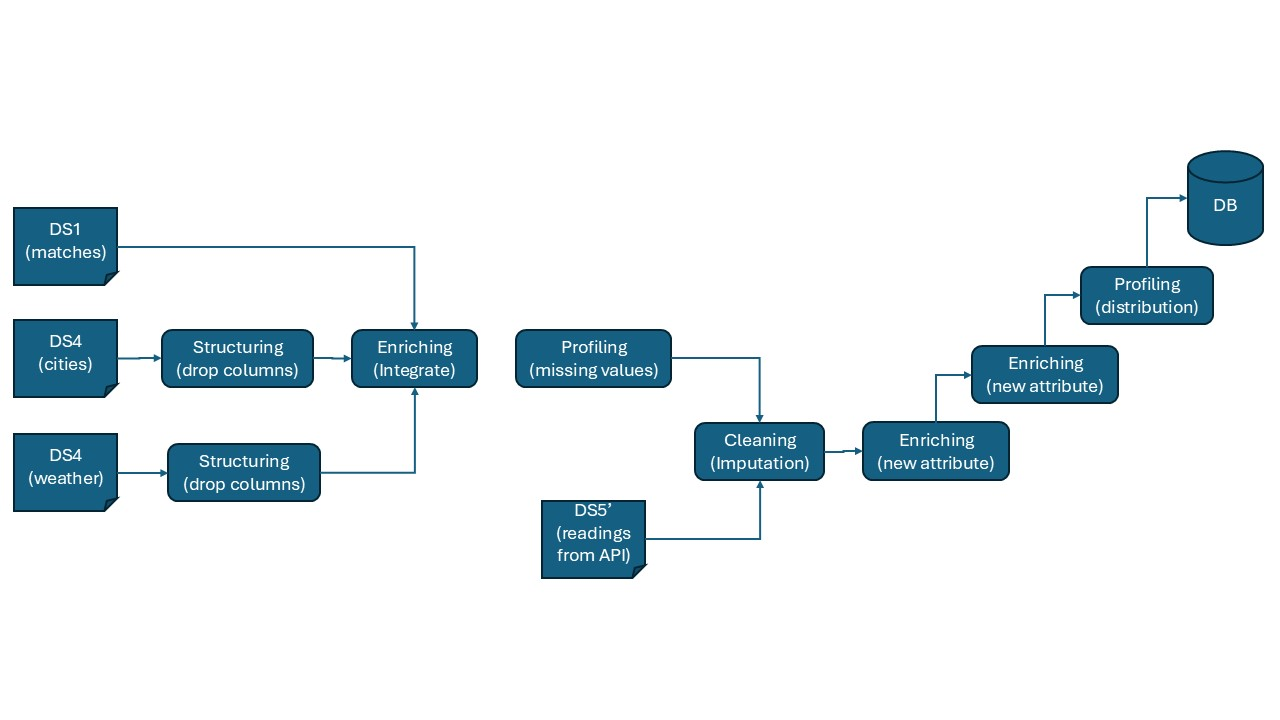

In [ ]:
#Open connection for this stage of processing
conn = sqlite3.connect('projectDB.sqlite')

### Structuring data from DS4

**Dropping irrelevant columns from cities.csv**

Some of the columns provided in the original file are irrelevant for our application. We remove these colums as part of a structuring operation.

In [ ]:
#Get data about station locations (data from DS4) with schema
#(station_id, city_name, country, latitude, longitude)
#This implements a first transformation where irrelevant columns from the source are removed (i.e., state, iso2, iso3)
sensor_loc_df = pd.read_csv('sample_data/cities.csv')
station_locations = sensor_loc_df.drop(columns=['state', 'iso2', 'iso3']).to_sql(name="station_locations", con=conn, if_exists='replace', index=False)


**Dropping irrelevant columns from the weather parquet file**

Similarly, we remove all attributes from the weather dataset that we recognized as being too sparse and too costly to fix through data imputation during our initial exploratory analysis of the datasets.

In [ ]:
#From the weather data, we only keep the usable attributes as determined by our
#exploratory analysis.
weather_data = df_weather.drop(columns=['city', 'avg_temp_c', 'snow_depth_mm',
                                        'avg_wind_dir_deg', 'avg_wind_speed_kmh',
                                        'peak_wind_gust_kmh', 'avg_sea_level_pres_hpa',
                               'sunshine_total_min'])

print(weather_data)

      station_id       date  season  min_temp_c  max_temp_c  precipitation_mm
0          41515 1957-07-01  Summer        21.1        35.6               0.0
1          41515 1957-07-02  Summer        18.9        32.2               0.0
2          41515 1957-07-03  Summer        16.7        35.6               1.0
3          41515 1957-07-04  Summer        16.1        37.8               4.1
4          41515 1957-07-05  Summer        20.0        41.7               0.0
...          ...        ...     ...         ...         ...               ...
24216      67975 2023-09-01  Spring         9.6        28.4               NaN
24217      67975 2023-09-02  Spring        10.5        31.4               NaN
24218      67975 2023-09-03  Spring        13.0        31.5               NaN
24219      67975 2023-09-04  Spring        13.1        29.7               NaN
24220      67975 2023-09-05  Spring        14.0        27.3               NaN

[27635763 rows x 6 columns]


### Enriching match data from DS1 through integration

Due to limited memory, we cannot directly load the weather data into a SQLite table. Therefore, we first filter the weather dataset to only include tuples with station_ids of match locations and weather readings on match dates. The result is then written to a database table such that we can perform the integration of the datasets via join operations.

In [ ]:
#Get data about match results (data from DS1) with schema
#(date,home_team, away_team,  home_score,  away_score, tournament, city, country, neutral)
match_results = df.to_sql(name="match_results", con=conn, if_exists='replace', index=False)


In [ ]:
#From weather_data, we are only interested in data matching a station_id at
#a match location, so we retrieve these stations and filter weather_data based
#on retrieved station_ids

sql_relevant_station_ids = "SELECT DISTINCT station_ID FROM match_results MR, station_locations SL \
  WHERE MR.city = SL.city_name AND MR.country = SL.country"
stations_with_matches = pd.read_sql(sql_relevant_station_ids, conn)

weather_data_filtered = weather_data[weather_data['station_id'].isin(stations_with_matches['station_id'])]

#we further prune the weather data based on match dates
sql_distinct_match_dates_with_stations = "SELECT DISTINCT date \
     FROM match_results MR, station_locations SL \
    WHERE MR.city = SL.city_name AND MR.country = SL.country"

distinct_match_dates = pd.read_sql(sql_distinct_match_dates_with_stations, conn)
#print(distinct_match_dates)

#we apply the match date filter and store the result in the DB
weather_data_filtered_2 = weather_data_filtered[weather_data_filtered['date'].isin(distinct_match_dates['date'])].to_sql(name="weather_data", con=conn, if_exists='replace', index=True)


<ipython-input-35-0e783a7cbb06>:20: FutureWarning: The behavior of 'isin' with dtype=datetime64[us] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  weather_data_filtered_2 = weather_data_filtered[weather_data_filtered['date'].isin(distinct_match_dates['date'])].to_sql(name="weather_data", con=conn, if_exists='replace', index=True)


In [ ]:
#We can now execute the following query to integrate the data
# to obtain matches with weather data and remove redundant or irrelevant columns

query1 = "SELECT MR.*, SL.station_id, SL.latitude, SL.longitude, WD.season, WD.min_temp_c, WD.max_temp_c, WD.precipitation_mm  \
  FROM match_results MR, station_locations SL, weather_data WD \
  WHERE MR.city = SL.city_name AND MR.country = SL.country \
  AND WD.station_id = SL.station_id AND WD.date = MR.date"
r1 = pd.read_sql(query1, conn)
print(r1)

                      date         home_team    away_team  home_score  \
0      1900-03-17 00:00:00  Northern Ireland      England           0   
1      1902-10-12 00:00:00           Austria      Hungary           5   
2      1903-10-11 00:00:00           Austria      Hungary           4   
3      1904-03-26 00:00:00  Northern Ireland     Scotland           1   
4      1904-05-01 00:00:00           Belgium       France           3   
...                    ...               ...          ...         ...   
18685  2023-08-27 00:00:00           Bolivia       Panama           1   
18686  2023-08-28 00:00:00           Comoros      Réunion           1   
18687  2023-08-28 00:00:00         Mauritius   Seychelles           1   
18688  2023-09-03 00:00:00        Bangladesh  Afghanistan           0   
18689  2023-09-04 00:00:00        Mozambique        Benin           3   

       away_score                            tournament          city  \
0               2             British Home Champio

### Profiling missing values

We verify the density of the data by counting the number of nulls per attribute. This corresponds to another round of profiling to reveal data quality issues that may need fixing prior to analysis.

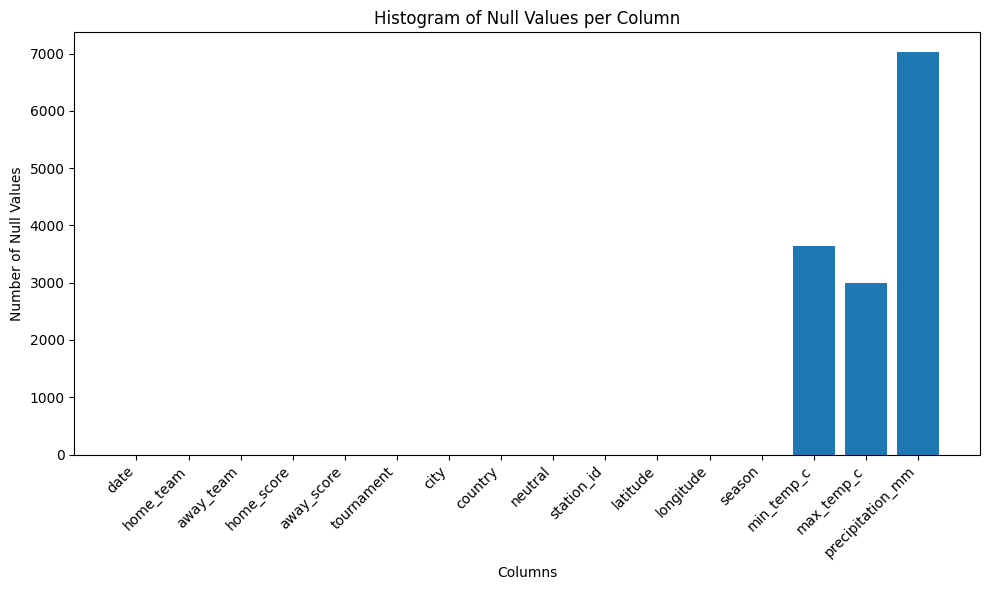

In [ ]:
null_counts = r1.isnull().sum()

plt.figure(figsize=(10, 6))
plt.bar(null_counts.index, null_counts.values)
plt.xlabel("Columns")
plt.ylabel("Number of Null Values")
plt.title("Histogram of Null Values per Column")
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for readability
plt.tight_layout()
plt.show()


### Data cleaning through data imputation

 As detected during our initial profiling, the weather data is sparse, and we use data from DS5 to perform data imputation for missing values (to be done once the required data is fully harvested.)

### Enriching by new attribute match_type

Our analysis does not require the distinction of different tournaments. However, we would like to keep the information of whether a match was a friendly match or a competitive match, as this may influence the quality of the selection playing or the motivation of players. This extends the table by an additional binary attribute.

In [ ]:

# Create the new column 'match_type'
r1['match_type'] = r1['tournament'].apply(lambda x: 0 if x == 'Friendly' else 1)

### Structuring by dropping tournament column

In [ ]:
r1.drop(columns=['tournament'], inplace=True)

print(r1)

                      date         home_team    away_team  home_score  \
0      1900-03-17 00:00:00  Northern Ireland      England           0   
1      1902-10-12 00:00:00           Austria      Hungary           5   
2      1903-10-11 00:00:00           Austria      Hungary           4   
3      1904-03-26 00:00:00  Northern Ireland     Scotland           1   
4      1904-05-01 00:00:00           Belgium       France           3   
...                    ...               ...          ...         ...   
18685  2023-08-27 00:00:00           Bolivia       Panama           1   
18686  2023-08-28 00:00:00           Comoros      Réunion           1   
18687  2023-08-28 00:00:00         Mauritius   Seychelles           1   
18688  2023-09-03 00:00:00        Bangladesh  Afghanistan           0   
18689  2023-09-04 00:00:00        Mozambique        Benin           3   

       away_score          city     country  neutral station_id   latitude  \
0               2        Dublin     Ireland  

### Enriching by new attribute climate_zone

To associate match locations with climate zones, we resort to a simple classification (as we could not find any secondary source for a more fine-grained enrichment). We follow the following definition:
*   Tropical: absolute latitude in [0, 23.5[
*   Subtropical: " [23.5, 40[
*   Temperate: " [40 - 60[
*   Cold:  " [60 - 90]





In [ ]:
def assign_climate_zone(latitude):
    latitude = abs(latitude)
    if 0 <= latitude < 23.5:
        return 'Tropical'
    elif 23.5 <= latitude < 40:
        return 'Subtropical'
    elif 40 <= latitude < 60:
        return 'Temperate'
    elif 60 <= latitude <= 90:
        return 'Cold'
    else:
        return 'Unknown'  # Handle cases outside the defined ranges

r1['climate_zone'] = r1['latitude'].apply(assign_climate_zone)

print(r1)


                      date         home_team    away_team  home_score  \
0      1900-03-17 00:00:00  Northern Ireland      England           0   
1      1902-10-12 00:00:00           Austria      Hungary           5   
2      1903-10-11 00:00:00           Austria      Hungary           4   
3      1904-03-26 00:00:00  Northern Ireland     Scotland           1   
4      1904-05-01 00:00:00           Belgium       France           3   
...                    ...               ...          ...         ...   
18685  2023-08-27 00:00:00           Bolivia       Panama           1   
18686  2023-08-28 00:00:00           Comoros      Réunion           1   
18687  2023-08-28 00:00:00         Mauritius   Seychelles           1   
18688  2023-09-03 00:00:00        Bangladesh  Afghanistan           0   
18689  2023-09-04 00:00:00        Mozambique        Benin           3   

       away_score          city     country  neutral station_id   latitude  \
0               2        Dublin     Ireland  


### Profiling value distribution of new attributes

We profile the new columns, looking at their value distributions. This helps us assess characteristics of the data that could impact the analyis.

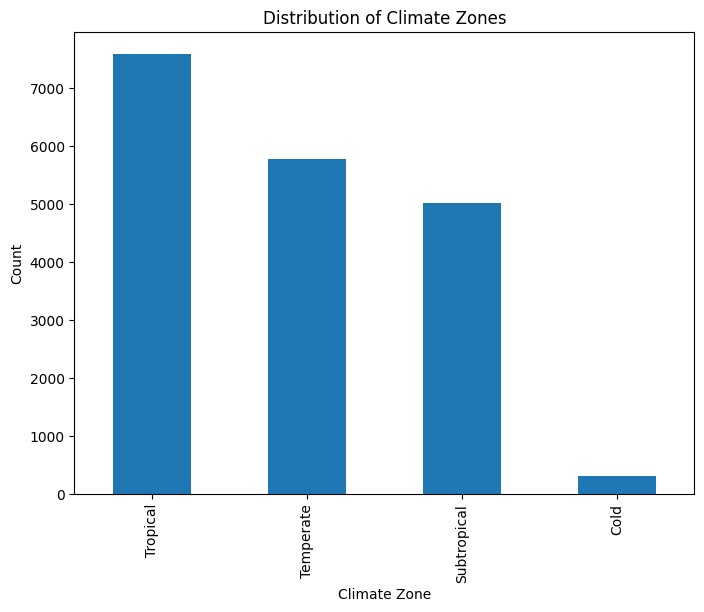

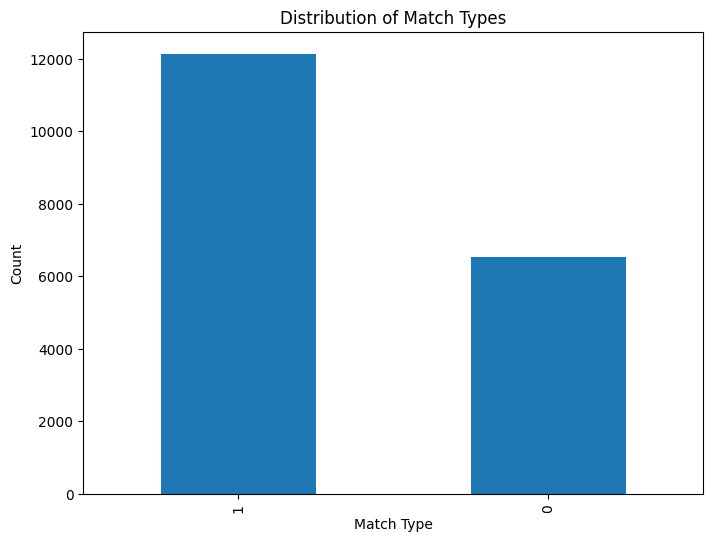

In [ ]:
# prompt: generate histogram for value distribution of climate_zone and match_type in r1


# Histogram for 'climate_zone'
plt.figure(figsize=(8, 6))
r1['climate_zone'].value_counts().plot(kind='bar')
plt.title('Distribution of Climate Zones')
plt.xlabel('Climate Zone')
plt.ylabel('Count')
plt.show()

# Histogram for 'match_type'
plt.figure(figsize=(8, 6))
r1['match_type'].value_counts().plot(kind='bar')
plt.title('Distribution of Match Types')
plt.xlabel('Match Type')  # 0 for Friendly, 1 for others
plt.ylabel('Count')
plt.show()


We note that matches in the cold climate zone are underrepresented, which is not surprising but may cause some bias during analysis if not dealt with properly. Match types are also unbalanced (in favor of competitive matches) and we will make dedicated analysis for each class.

In [ ]:
r1.to_csv('r1.csv')
conn.close()

## Data Analysis (Analyze)


> *Clearly state which type of analysis you conduct (descriptive, diagnostic, predictive, prescriptive) and the methods you use (e.g., time series decomposition, root cause analysis, etc.). Your project should include at least one analysis. When conducting several analysis techniques / methods, specify each of them.*





Given that our ovarching goal is to determine if there is a relationship between match results and climate conditions, we apply the following methods from descriptive / diagnostic analytics:

*   Visualization (Descriptive analysis)
*   Relationship and dependency analysis (Diagnostic analysis)
*   Hypothesis testing and validation (Diagnostic analysis)
*  ...


In [ ]:
#read input file for analysis
df = pd.read_csv('sample_data/r1.csv')



> *For each analysis, briefly describe its goal, justify the methods / measures used, show the code performing the analysis, interpret the result, and discuss possible limitations of your approach. Follow the structure as illustrated below.*


### Visualization

**Goal:** The goal is to visually describe the distribution of scores for the different climate zones.

**Methods / measures:** We use box plots as compact visualization of each distribution.

**Code:** For each climate zone, we generate a box plot.

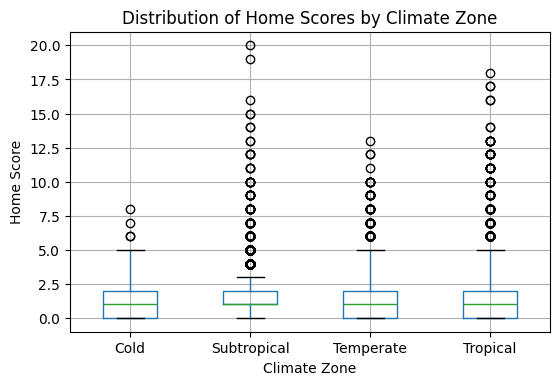

In [ ]:
# Create the box plot
df.boxplot(column='home_score', by='climate_zone', figsize=(6, 4))
plt.title('Distribution of Home Scores by Climate Zone')
plt.suptitle('')  # Remove the default suptitle
plt.ylabel('Home Score')
plt.xlabel('Climate Zone')
plt.show()


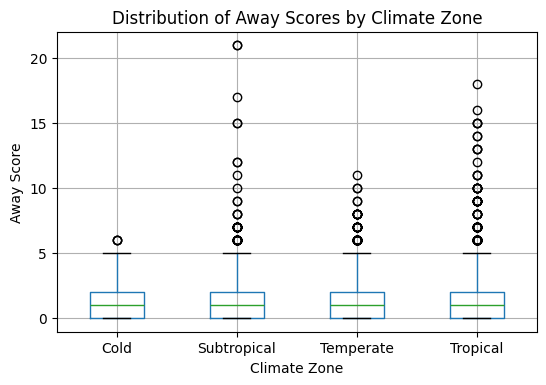

In [ ]:
# Create the box plot
df.boxplot(column='away_score', by='climate_zone', figsize=(6, 4))
plt.title('Distribution of Away Scores by Climate Zone')
plt.suptitle('')  # Remove the default suptitle
plt.ylabel('Away Score')
plt.xlabel('Climate Zone')
plt.show()


**Interpretation.** The mean and measures of dispersion visualized by the boxplot indicate a comparable distribution for both home and away scores in different climate zones. We observe a high range of values in subtropical and tropica regions, while it is smaller in the cold region. However, as we have noticed while profiling our data, the cold region is underrepresented in the dataset so we must be cautious in drawing any conclusion here.

**Limitations.** We are aware that our division into climate zones is very coarse grained and generic, which may cause hidden relationships not to be discovered. Using the above visual analysis gives an indication that there is no significant difference in score distribution within the selected climate zones, but drawing a general conclusion based on our data sample would require some follow-up statistical analysis (see hypothesis testing below).

### Relationship and dependency analysis

**Goal.**
The goal is to identify if there is a relationship between match results and weather during matches / climate at match location.

**Methods / measures.**
We apply a correlation analysis. Given that we are not dealing with continuous data only and the type of data and distribution of, the Spearman correlation is the more appropriate choice.

**Code.** The following code computes the Spearman correlation between match score summaries (i.e., sum of goals, goal difference, max goals, min goals) and climate factors(i.e., precipitation, maximum temperature, combination of season and climate zone).

In [ ]:
#add columns for score summaries

df['sum_goals'] = df['home_score'] + df['away_score']
df['goals_diff'] = abs(df['home_score'] - df['away_score'])
df['max_goals'] = df[['home_score', 'away_score']].max(axis=1)
df['min_goals'] = df[['home_score', 'away_score']].min(axis=1)

#add additional column combining season and climate_zone
df['season_climate_zone'] = df['season'] + '_' + df['climate_zone']


In [ ]:
# Remove rows where 'precipitation_mm' is NaN
#df_cleaned_for_corr = df.dropna(subset=['precipitation_mm'])


score_summary_columns = ['sum_goals', 'goals_diff', 'max_goals', 'min_goals']

#Spearman correlation wrt season_climnate_zone
for score_col in score_summary_columns:
  correlation, p_value = stats.spearmanr(df[score_col], df['season_climate_zone'])
  print(f"Spearman correlation between {score_col} and {'season_climante_zone'}: {correlation}, p-value: {p_value}")

#Spearman correlation wrt precipitation_mm where we need to remove NaN values
df_cleaned_for_corr = df.dropna(subset=['precipitation_mm'])
for score_col in score_summary_columns:
  correlation, p_value = stats.spearmanr(df_cleaned_for_corr[score_col], df_cleaned_for_corr['precipitation_mm'])
  print(f"Spearman correlation between {score_col} and {'precipitation_mm'}: {correlation}, p-value: {p_value}")

#Spearman correlation wrt max_temp_c where we need to remove NaN values
df_cleaned_for_corr_maxT = df.dropna(subset=['max_temp_c'])
for score_col in score_summary_columns:
  correlation, p_value = stats.spearmanr(df_cleaned_for_corr_maxT[score_col], df_cleaned_for_corr_maxT['max_temp_c'])
  print(f"Spearman correlation between {score_col} and {'max_temp_c'}: {correlation}, p-value: {p_value}")



Spearman correlation between sum_goals and season_climante_zone: -0.01244991052362495, p-value: 0.0887560239654214
Spearman correlation between goals_diff and season_climante_zone: -0.03302790325944699, p-value: 6.295323682556515e-06
Spearman correlation between max_goals and season_climante_zone: -0.023715552280550688, p-value: 0.0011851718190513435
Spearman correlation between min_goals and season_climante_zone: 0.015500762829373278, p-value: 0.03408065091844771
Spearman correlation between sum_goals and precipitation_mm: 0.03159636237696675, p-value: 0.0006403592999509602
Spearman correlation between goals_diff and precipitation_mm: 0.03197081846449606, p-value: 0.0005515240787141272
Spearman correlation between max_goals and precipitation_mm: 0.03585268125381395, p-value: 0.00010702743414413086
Spearman correlation between min_goals and precipitation_mm: 0.010657736132196205, p-value: 0.24961286261927504
Spearman correlation between sum_goals and max_temp_c: -0.0015862704487504395,

**Interpretation.**
All correlation scores are close to 0, meaning that no relationship between the studied combinations of score-climate-factores can be detected.

**Limitations**. The above analysis does not take into account the region teams come from. This may be an additional factor to consider. Goal-related statistics may not be the only relevant statistics to assess game play, but it is what we obtained from the data sources we found and could use.

### Hypothesis testing

**Goal.** Given the results of our visual analysis, we want to determine if cold climate / cold game conditions significantly affect match results, as we have observed that these are lower for the Cold climate zone than for the others.

**Methods / Measures.** We use hypothesis testing. Our Null-hypothesis is that there is no difference between match results (we will focus home_score and away_score) in Cold climate / weather (below 10 degrees) and warmer weather. The alternative hypothesis is that there is a significant difference. As test statistics, we choose the Mann-Whitney U test given that we compare two non-normal distributions of same shape (see first visualization of the code section) with a continuous dependent variable (score) and an independent variable "climate" with two groups (COLD/WARM).

**Code.** The first part of our code is used to determine which statistical test to use. The second part performs the test based on the climate zone and the temperature, respectively.

In [ ]:
# Create TEMP_CLASS column based on max_temp_c
df['TEMP_CLASS'] = np.where(df['max_temp_c'] < 10, 'COLD', 'WARM')

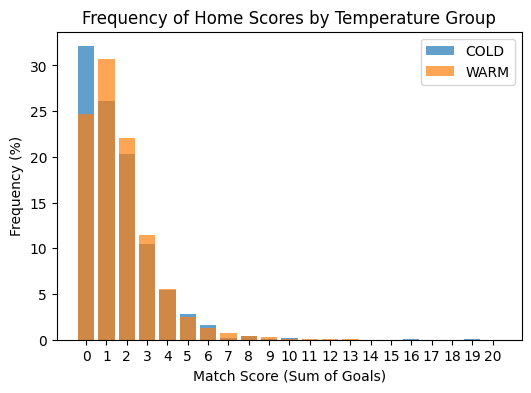

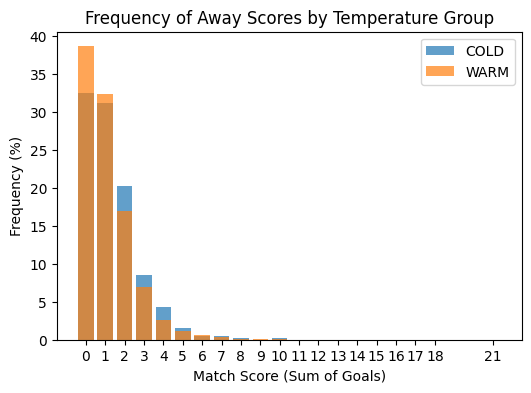

In [ ]:
#We compare the distribution of scores among the different groups to see if it follows a normal distribution or has similar shape across groups.
#Given the high difference in number of samples in both classes profiled before, we make a %-wise comparison
# Group data based on max_temp_c
cold_group = df[df['TEMP_CLASS'] == 'COLD']
warm_group = df[df['TEMP_CLASS'] == 'WARM']

# Calculate total matches for each group
total_cold_matches = len(cold_group)
total_warm_matches = len(warm_group)

# Function to calculate score frequencies for home_score
def calculate_score_frequencies(group, total_matches, att):
    score_frequencies = group[att].value_counts(normalize=True) * 100
    return score_frequencies

# Calculate score frequencies for each group
cold_frequencies_hs = calculate_score_frequencies(cold_group, total_cold_matches,'home_score')
warm_frequencies_hs = calculate_score_frequencies(warm_group, total_warm_matches, 'home_score')

cold_frequencies_as = calculate_score_frequencies(cold_group, total_cold_matches,'away_score')
warm_frequencies_as = calculate_score_frequencies(warm_group, total_warm_matches, 'away_score')


# Plotting
plt.figure(figsize=(6, 4))
plt.bar(cold_frequencies_hs.index, cold_frequencies_hs.values, label='COLD', alpha=0.7)
plt.bar(warm_frequencies_hs.index, warm_frequencies_hs.values, label='WARM', alpha=0.7)

plt.xlabel('Match Score (Sum of Goals)')
plt.ylabel('Frequency (%)')
plt.title('Frequency of Home Scores by Temperature Group')
plt.legend()
plt.xticks(list(set(cold_frequencies_hs.index).union(set(warm_frequencies_hs.index)))) # Ensure all scores are shown on x-axis
plt.show()

plt.figure(figsize=(6, 4))
plt.bar(cold_frequencies_as.index, cold_frequencies_as.values, label='COLD', alpha=0.7)
plt.bar(warm_frequencies_as.index, warm_frequencies_as.values, label='WARM', alpha=0.7)

plt.xlabel('Match Score (Sum of Goals)')
plt.ylabel('Frequency (%)')
plt.title('Frequency of Away Scores by Temperature Group')
plt.legend()
plt.xticks(list(set(cold_frequencies_as.index).union(set(warm_frequencies_as.index)))) # Ensure all scores are shown on x-axis
plt.show()





In [ ]:
#Perform statistical test

statistic_hs, p_value_hs = stats.mannwhitneyu(cold_group['home_score'], warm_group['home_score'])

print(f"Mann-Whitney U statistic for 'home_score': {statistic_hs}")
print(f"P-value  for 'home_score': {p_value_hs}")

# Perform the Mann-Whitney U test for away_score
statistic_as, p_value_as = stats.mannwhitneyu(cold_group['home_score'], warm_group['home_score'])

print(f"Mann-Whitney U statistic for 'away_score': {statistic_as}")
print(f"P-value  for 'away_score': {p_value_hs}")

Mann-Whitney U statistic for 'home_score': 9041248.0
P-value  for 'home_score': 0.0005200781522565829
Mann-Whitney U statistic for 'away_score': 9041248.0
P-value  for 'away_score': 0.0005200781522565829


**Interpretation.** From the statistical test, we observe that there is a statistical difference in achieved score (both for the home and away teams) when weather is cold as opposed to when weather is hot.

**Limitation.** The number of samples for COLD and WARM class is highly unbalanced, which may lead to distorted conclusions. The statistical test is further designed for independent groups but same players could play (at different times, in different team compositions) in both groups.

# Presentation of main results (Share)



> *Create a visualization, summary, infographic, or any other way you see fit to present the main findings (at least one, may be more). Structure the discussion in three parts: (1) Stakeholder: who are you presenting to in your use case; (2) visualization/summary/infographic (can be code to be executed, text, image, etc.); (3) Short narrative of final result to stakeholders.*



## Stakeholders

The results are presented to football coaches of national teams.



## Visualization

<ipython-input-93-75e2caf3ee7b>:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  max_home_scores_per_bin = df.groupby('temperature_bin')['home_score'].max()


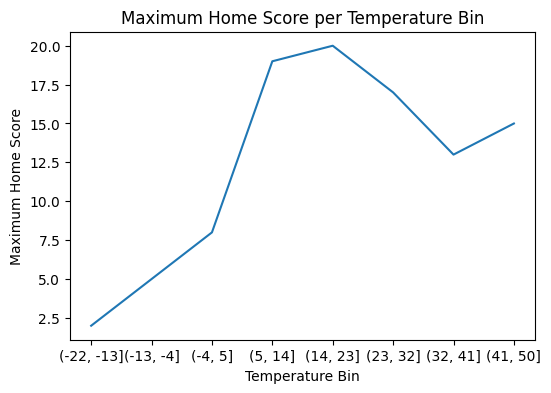

In [ ]:
# Create bins for temperature
df['temperature_bin'] = pd.cut(df['max_temp_c'], bins=range(int(df['max_temp_c'].min()), int(df['max_temp_c'].max()) + 9, 9))

# Group by temperature bin and get the maximum home score for each bin
max_home_scores_per_bin = df.groupby('temperature_bin')['home_score'].max()

# Create the line plot
plt.figure(figsize=(6, 4))
plt.plot(max_home_scores_per_bin.index.astype(str), max_home_scores_per_bin.values)
plt.xlabel('Temperature Bin')
plt.ylabel('Maximum Home Score')
plt.title('Maximum Home Score per Temperature Bin')
plt.show()

<ipython-input-94-4d0918230f21>:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  max_home_scores_per_bin = df.groupby('temperature_bin')['away_score'].max()


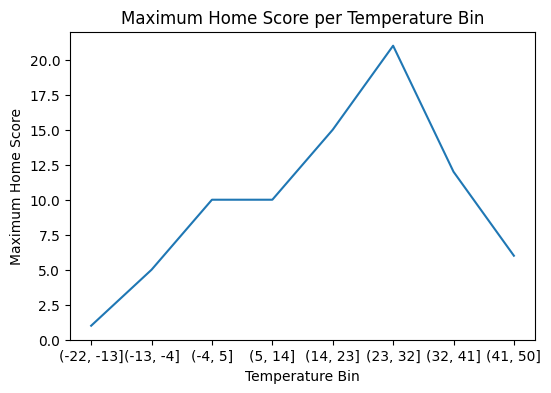

In [ ]:
# Group by temperature bin and get the maximum home score for each bin
max_home_scores_per_bin = df.groupby('temperature_bin')['away_score'].max()

# Create the line plot
plt.figure(figsize=(6, 4))
plt.plot(max_home_scores_per_bin.index.astype(str), max_home_scores_per_bin.values)
plt.xlabel('Temperature Bin')
plt.ylabel('Maximum Home Score')
plt.title('Maximum Home Score per Temperature Bin')
plt.show()

**Narrative**. Our detailed analysis of the difference of both home_score and away_score depending on climatic conditions (cold as defined by < 10 degress C) and warm (>= 10 degrees C) has revealed a significant difference. The graphs show the discovered trend, where on lower temperatures, the maximum number of goals achieved in any game is much lower than at higher temperatures.  

# Possible actions based on results (Act)



> *Provide a brief description of possible actions to be derived from your data-based insights.*



Training plans could be adapted to better prepare players for cold weather conditions especially if upcoming tournaments are in the Cold climate zone.

# Final Reflection



> *Briefly reflect on possible issues or limitations with respect to data ethics and data privacy/security. Structure as illustrated below, i.e., one sub-section for each aspect.*



## Considerations on data ethics

Given the available data, the results only apply to professional national teams, already benefiting from comprehensive measures for top-performance. Non-professional / more local teams are not considered, while they may potentially benefit most from this type of study.

We did not keep track of metadata giving credit / showing attribution to the different sources and dataset authors. If we decided to publish the derived dataset or notebook, we would neet to make sure proper attribution is given and ensure data use is compliant with licences.

## Considerations on data privacy and security

Being purely based on open data without any personal information, there are no special risks or measures to be taken to ensure data privacy or security when considering a data science deployment.